In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob 
from skimage.io import imread
from skimage.filters import threshold_multiotsu

Here we compute the signal to noise ratio as a metric of image quality. To define background and signal, we use otsu thresholding. 
However, the idea of otsu thresholding works if signal was bimodal, which it isn't in our data (see example below)

In [3]:
path0 = '../../'
panel = pd.read_csv(path0+'/combined_tiff/Leap001/panel.csv',index_col=0)
panel = panel[panel.keep]
base_dir = path0+'Img_Denoised'
file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension
biosamples_path = path0+'IMC_data/ExtraDocs/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)
biosamples

# Create a pattern to search for subdirectories with names starting with 'Leap'
sub_dir_pattern = os.path.join(base_dir, 'Leap*')
tb = pd.DataFrame(glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True),columns = ['filepath'])
acq_mark = pd.DataFrame(list(tb.filepath.str.split('/').str[-2:]),columns = ['acquisition','marker'])
acq_mark['marker'] = acq_mark.marker.str.rstrip('.tiff')
tb = pd.concat([tb,acq_mark],axis=1)

In [19]:
def quality_control(filename):
    image = imread(filename)
    thresholds = threshold_multiotsu(image,classes=2)
    # Using the threshold values, we generate two regions, background and foregroung
    is_fg = np.digitize(image, bins=thresholds).astype(bool)
    s_i = image[is_fg].mean() #mean signal intensity
    snr = s_i/(image[~is_fg].mean())#ratio:  foregroud/backgroud
    image = skimage.exposure.rescale_intensity(image,in_range=(0, 1))
    e = entropy(image,disk(5)).mean()
    return s_i,snr,e
with multiprocessing.Pool() as pool:
     data = pool.map(quality_control, tb.filepath)
tb[['signal_intensity','snr','entropy']] = data    

/home/giuseppe/anaconda3/lib/python3.9/multiprocessing/pool.py:48: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return list(map(*args))
/home/giuseppe/anaconda3/lib/python3.9/multiprocessing/pool.py:48: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return list(map(*args))
/home/giuseppe/anaconda3/lib/python3.9/multiprocessing/pool.py:48: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return list(map(*args))
/home/giuseppe/anaconda3/lib/python3.9/multiprocessing/pool.py:48: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. 

In [20]:
tb.to_csv('data/quality_metrics.csv',index=False)

In [4]:
tb = pd.read_csv('data/quality_metrics')

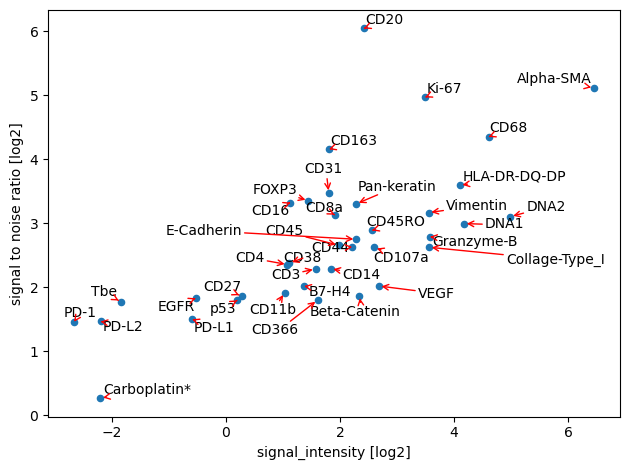

In [21]:
from adjustText import adjust_text
q_metrics = tb.groupby('marker')[['signal_intensity','snr','entropy']].median()
q_metrics.drop('Carboplatin',axis = 0,inplace=True)
#for carboplatin, we take only the resection images
tb['LEAP_ID'] = tb.acquisition.str.split('_',n = 1).str[0].str.upper()
a = tb.merge(biosamples,left_on='LEAP_ID',right_on='LEAP_ID')
cond=(a['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION')*(a['marker']=='Carboplatin')
q_metrics = pd.concat((q_metrics,tb[cond].groupby('marker')[q_metrics.columns].median())).rename(index={'Carboplatin': 'Carboplatin*'})

#np.log2(q_metrics).plot(x = 'signal_intensity',y='snr',kind='scatter',c = q_metrics.entropy,colormap='jet' )
np.log2(q_metrics).plot(x = 'signal_intensity',y='snr',kind='scatter' )
plt.xlabel('signal_intensity [log2]')
plt.ylabel('signal to noise ratio [log2]')
a = [plt.annotate(text,(b,c)) for text,(b,c,_) in np.log2(q_metrics)[['signal_intensity','snr','entropy']].iterrows()]
adjust_text(a, arrowprops=dict(arrowstyle='->', color='red'))
plt.tight_layout()
#plt.savefig('qc_noise.png')

In [105]:
tb

,filepath,acquisition,marker,signal_intensity,snr,entropy
0,../../split_channels/Leap081_8/B7-H4.tiff,Leap081_8,B7-H4,6.667931,7.831017,0.848994
1,../../split_channels/Leap081_8/Alpha-SMA.tiff,Leap081_8,Alpha-SMA,132.411224,23.627890,0.754157
2,../../split_channels/Leap081_8/CD107a.tiff,Leap081_8,CD107a,27.111021,11.776258,0.806568
3,../../split_channels/Leap081_8/CD8a.tiff,Leap081_8,CD8a,5.022711,9.934290,0.879207
4,../../split_channels/Leap081_8/CD14.tiff,Leap081_8,CD14,16.654545,9.227174,0.814387
...,...,...,...,...,...,...
33397,../../split_channels/Leap017_15/Ki-67.tiff,Leap017_15,Ki-67,3.464625,49.537167,0.339447
33398,../../split_channels/Leap017_15/CD163.tiff,Leap017_15,CD163,1.384523,1751.064331,0.353057
33399,../../split_channels/Leap017_15/CD16.tiff,Leap017_15,CD16,274.498993,1316.728760,0.523659
33400,../../split_channels/Leap017_15/DNA2.tiff,Leap017_15,DNA2,21.620333,10.173416,0.552763


In [54]:

#tb.acquisition

,signal_intensity,snr
marker,,
Alpha-SMA,87.511100,34.628033
B7-H4,2.588905,4.048095
Beta-Catenin,5.067290,3.652313
CD107a,6.066687,6.150761
CD11b,2.042251,3.770552
CD14,3.568416,4.889619
CD163,3.760175,22.775917
CD20,5.345884,65.944290
CD27,1.213517,3.621787


show an example where this is done for one image

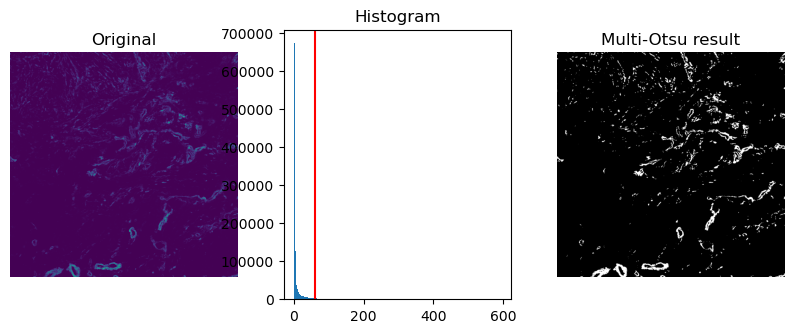

In [105]:
filename = tb['filepath'][1]
image = imread(filename)
# Using the threshold values, we generate the three regions.
regions = np.digitize(image, bins=thresholds)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.5))

# Plotting the original image.
ax[0].imshow(image)
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='gray')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.subplots_adjust()

plt.show()

In [122]:
cond = regions.astype(bool)
snr = image[cond].mean()/image[~cond].mean()#ratio:  foregroud/backgroud


array([0.11230808, 0.10788874, 0.11607769, ..., 2.6149714 , 1.3270744 ,
       1.2066847 ], dtype=float32)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[]

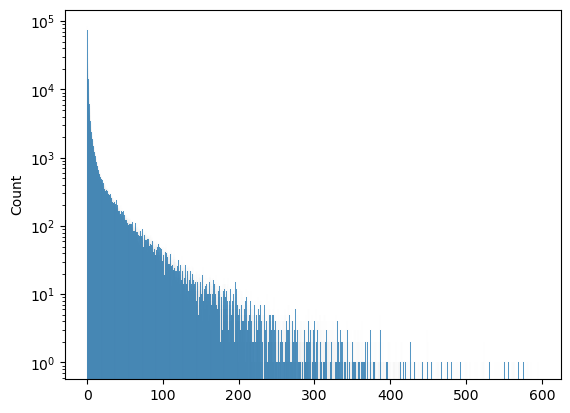

In [113]:
#sns.histplot(image2.reshape(-1))
sns.histplot(image.reshape(-1))
plt.semilogy()

In [80]:
np.unique(regions.reshape(-1))

array([0, 1])

In [11]:
size = []
for el in tb.filepath:
    img = imread(el)
    size+=[(img.shape)]


(1018, 1095)